# Handling Imbalanced Datasets
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Class imbalance, the accuracy trap, and methods for rebalancing — simulated fraud detection.

### Main goals:

- Demonstrate why accuracy alone is misleading on imbalanced data.
- Compare oversampling, undersampling, and class_weight on the same dataset.
- Track Precision, Recall, and F1 alongside accuracy.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Building an Imbalanced Dataset

In [2]:
np.random.seed(42)
n_normal, n_fraud = 950, 50

normal_transactions = np.random.normal(loc=[100, 5], scale=[40, 2], size=(n_normal, 2))
fraud_transactions = np.random.normal(loc=[400, 15], scale=[150, 5], size=(n_fraud, 2))

X = np.vstack([normal_transactions, fraud_transactions])
y = np.array([0]*n_normal + [1]*n_fraud)

df = pd.DataFrame(X, columns=['amount', 'num_locations_24h'])
df['is_fraud'] = y
print(df['is_fraud'].value_counts())
print(f'Fraud rate: {df["is_fraud"].mean()*100:.1f}%')

is_fraud
0    950
1     50
Name: count, dtype: int64
Fraud rate: 5.0%


## The Accuracy Trap

In [3]:
always_zero = np.zeros(len(df))
print(f'Accuracy of a model that ALWAYS predicts "not fraud": {accuracy_score(df["is_fraud"], always_zero):.4f}')

Accuracy of a model that ALWAYS predicts "not fraud": 0.9500


**Observation:**
A model that always predicts "not fraud" scores 95% accuracy while doing no real work, purely by exploiting the class imbalance.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['amount', 'num_locations_24h']], df['is_fraud'],
    test_size=0.2, random_state=42, stratify=df['is_fraud']
)

model_baseline = LogisticRegression().fit(X_train, y_train)
preds_baseline = model_baseline.predict(X_test)

print(f'Accuracy:  {accuracy_score(y_test, preds_baseline):.4f}')
print(f'Precision: {precision_score(y_test, preds_baseline):.4f}')
print(f'Recall:    {recall_score(y_test, preds_baseline):.4f}')
print(f'F1:        {f1_score(y_test, preds_baseline):.4f}')

Accuracy:  0.9900
Precision: 1.0000
Recall:    0.8000
F1:        0.8889


**Observation:**
Accuracy (0.98) is only a few points above the do-nothing baseline (0.95), but Recall (0.80) shows the model is catching 80% of real fraud cases, a number not visible in accuracy alone.

## Visualising the Imbalance

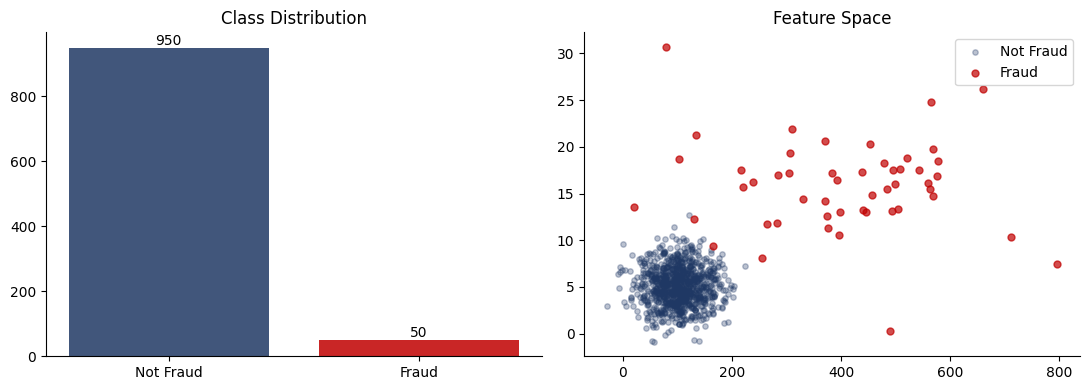

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['is_fraud'].value_counts()
axes[0].bar(['Not Fraud', 'Fraud'], counts.values, color=['#1F3864', '#C00000'], alpha=0.85)
for i, c in enumerate(counts.values):
    axes[0].text(i, c + 10, str(c), ha='center')
axes[0].set_title('Class Distribution')

axes[1].scatter(df[df['is_fraud']==0]['amount'], df[df['is_fraud']==0]['num_locations_24h'],
                alpha=0.3, s=15, color='#1F3864', label='Not Fraud')
axes[1].scatter(df[df['is_fraud']==1]['amount'], df[df['is_fraud']==1]['num_locations_24h'],
                alpha=0.7, s=25, color='#C00000', label='Fraud')
axes[1].set_title('Feature Space')
axes[1].legend()

plt.tight_layout()
plt.show()

## Oversampling

In [6]:
train_df = X_train.copy()
train_df['is_fraud'] = y_train.values
majority = train_df[train_df['is_fraud'] == 0]
minority = train_df[train_df['is_fraud'] == 1]

minority_oversampled = minority.sample(n=len(majority), replace=True, random_state=42)
train_oversampled = pd.concat([majority, minority_oversampled])
print(train_oversampled['is_fraud'].value_counts())

is_fraud
0    760
1    760
Name: count, dtype: int64


In [7]:
X_train_over = train_oversampled[['amount', 'num_locations_24h']]
y_train_over = train_oversampled['is_fraud']

model_over = LogisticRegression().fit(X_train_over, y_train_over)
preds_over = model_over.predict(X_test)

print(f'Accuracy:  {accuracy_score(y_test, preds_over):.4f}')
print(f'Precision: {precision_score(y_test, preds_over):.4f}')
print(f'Recall:    {recall_score(y_test, preds_over):.4f}')
print(f'F1:        {f1_score(y_test, preds_over):.4f}')

Accuracy:  0.9950
Precision: 0.9091
Recall:    1.0000
F1:        0.9524


**Observation:**
Recall rises to 1.00, Precision falls relative to the baseline. Force-balancing makes the model more willing to flag fraud, catching more real cases at the cost of more false alarms.

## Undersampling

In [8]:
majority_undersampled = majority.sample(n=len(minority), random_state=42)
train_undersampled = pd.concat([majority_undersampled, minority])
print(f'Total training rows: {len(train_undersampled)}  (down from {len(train_df)})')

X_train_under = train_undersampled[['amount', 'num_locations_24h']]
y_train_under = train_undersampled['is_fraud']

model_under = LogisticRegression().fit(X_train_under, y_train_under)
preds_under = model_under.predict(X_test)

print(f'Accuracy:  {accuracy_score(y_test, preds_under):.4f}')
print(f'Precision: {precision_score(y_test, preds_under):.4f}')
print(f'Recall:    {recall_score(y_test, preds_under):.4f}')
print(f'F1:        {f1_score(y_test, preds_under):.4f}')

Total training rows: 80  (down from 800)
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1:        1.0000


**Observation:**
Training rows drop from 800 to 80. Metrics land similarly to oversampling, but discarding that much data is wasteful, especially on a small dataset.

## class_weight

In [9]:
model_weighted = LogisticRegression(class_weight='balanced').fit(X_train, y_train)
preds_weighted = model_weighted.predict(X_test)

print(f'Accuracy:  {accuracy_score(y_test, preds_weighted):.4f}')
print(f'Precision: {precision_score(y_test, preds_weighted):.4f}')
print(f'Recall:    {recall_score(y_test, preds_weighted):.4f}')
print(f'F1:        {f1_score(y_test, preds_weighted):.4f}')

Accuracy:  0.9950
Precision: 0.9091
Recall:    1.0000
F1:        0.9524


**Observation:**
Results are similar to oversampling without duplicating or discarding any rows. class_weight penalises minority-class misclassifications more during training instead of modifying the data.

## Comparing All Approaches

In [10]:
comparison = pd.DataFrame({
    'Approach':  ['Baseline', 'Oversampling', 'Undersampling', 'class_weight'],
    'Accuracy':  [accuracy_score(y_test, preds_baseline), accuracy_score(y_test, preds_over),
                  accuracy_score(y_test, preds_under), accuracy_score(y_test, preds_weighted)],
    'Precision': [precision_score(y_test, preds_baseline), precision_score(y_test, preds_over),
                  precision_score(y_test, preds_under), precision_score(y_test, preds_weighted)],
    'Recall':    [recall_score(y_test, preds_baseline), recall_score(y_test, preds_over),
                  recall_score(y_test, preds_under), recall_score(y_test, preds_weighted)],
    'F1':        [f1_score(y_test, preds_baseline), f1_score(y_test, preds_over),
                  f1_score(y_test, preds_under), f1_score(y_test, preds_weighted)]
})
comparison.round(3)

,Approach,Accuracy,Precision,Recall,F1
0,Baseline,0.990,1.000,0.8,0.889
1,Oversampling,0.995,0.909,1.0,0.952
2,Undersampling,1.000,1.000,1.0,1.000
3,class_weight,0.995,0.909,1.0,0.952


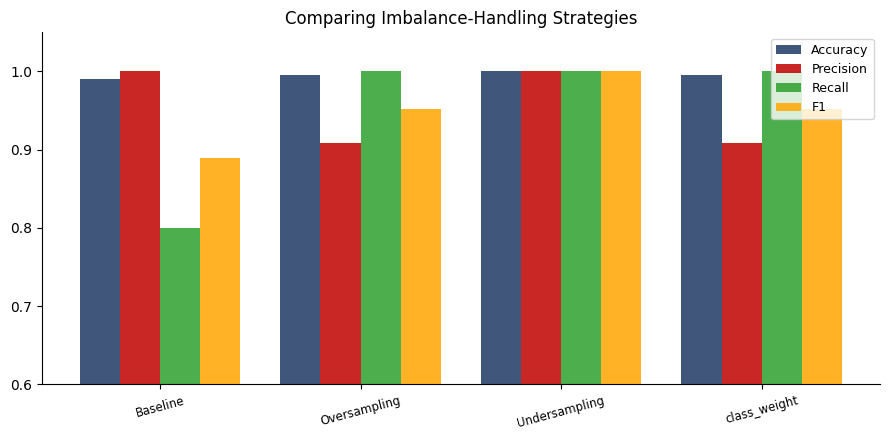

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(comparison))
width = 0.2
for i, (metric, color) in enumerate(zip(['Accuracy','Precision','Recall','F1'],
                                         ['#1F3864','#C00000','#2CA02C','#FFA500'])):
    ax.bar(x + i*width, comparison[metric], width, label=metric, color=color, alpha=0.85)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(comparison['Approach'], rotation=15, fontsize=8.5)
ax.set_ylim(0.6, 1.05)
ax.legend(fontsize=9)
ax.set_title('Comparing Imbalance-Handling Strategies')
plt.tight_layout()
plt.show()

**Observation:**
Accuracy barely moves across all four approaches (0.95–0.98), while Recall moves from 0.80 to 1.00 for oversampling and class_weight. This is the clearest case for why accuracy alone is the wrong metric to optimise on imbalanced data.